In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import clear_output
import time

In [ ]:
# Q-1. Compare the Loss functions

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8  # to avoid log(0)
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))


In [ ]:
# Training function for single-layer model
def train_single_neuron(X, y, loss_type='mse', epochs=2000, lr=0.01, use_sigmoid=False):
    n_samples, n_features = X.shape
    w = np.random.randn(n_features, 1)
    b = 0
    loss_history = []

    for epoch in range(epochs):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z) if use_sigmoid else z
        if loss_type == 'bce':
            loss = binary_cross_entropy(y, y_pred)
            dz = y_pred - y
        elif loss_type == 'mse':
            loss = mean_squared_error(y, y_pred)
            dz = 2 * (y_pred - y) / n_samples
        dw = np.dot(X.T, dz)
        db = np.sum(dz)
        w -= lr * dw
        b -= lr * db

        loss_history.append(loss)

    return loss_history


In [ ]:
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
y_reg = y_reg.reshape(-1, 1)

scaler_Xr = StandardScaler()
scaler_yr = StandardScaler()
X_reg = scaler_Xr.fit_transform(X_reg)
y_reg = scaler_yr.fit_transform(y_reg)

mse_loss = train_single_neuron(X_reg, y_reg, loss_type='mse', use_sigmoid=False)

In [ ]:
X_cls, y_cls = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=1
)
y_cls = y_cls.reshape(-1, 1)

scaler_Xc = StandardScaler()
X_cls = scaler_Xc.fit_transform(X_cls)

bce_losses = train_classification(X_cls, y_cls)


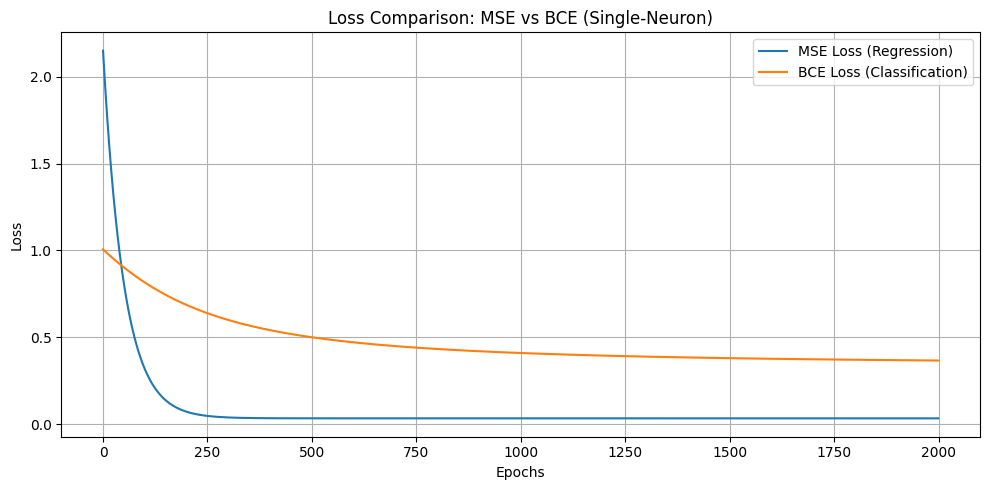

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(mse_losses, label="MSE Loss (Regression)")
plt.plot(bce_losses, label="BCE Loss (Classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison: MSE vs BCE (Single-Neuron)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Q-2: Compare Learning Rate Effects (Sigmoid + BCE)


def train_binary(X, y, lr, epochs=100):
    n_samples, n_features = X.shape
    w = np.random.randn(n_features, 1)
    b = 0
    losses = []

    for epoch in range(epochs):
        z = X.dot(w) + b
        y_pred = sigmoid(z)

        loss = binary_cross_entropy(y, y_pred)
        losses.append(loss)

        dz = y_pred - y
        dw = (X.T.dot(dz)) / n_samples
        db = np.sum(dz) / n_samples

        w -= lr * dw
        b -= lr * db

    return losses

In [ ]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=0
)
y = y.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [ ]:
learning_rates = [0.01, 0.1, 1]
loss_histories = {}

for lr in learning_rates:
    losses = train_binary(X_train, y_train, lr=lr, epochs=100)
    loss_histories[lr] = losses


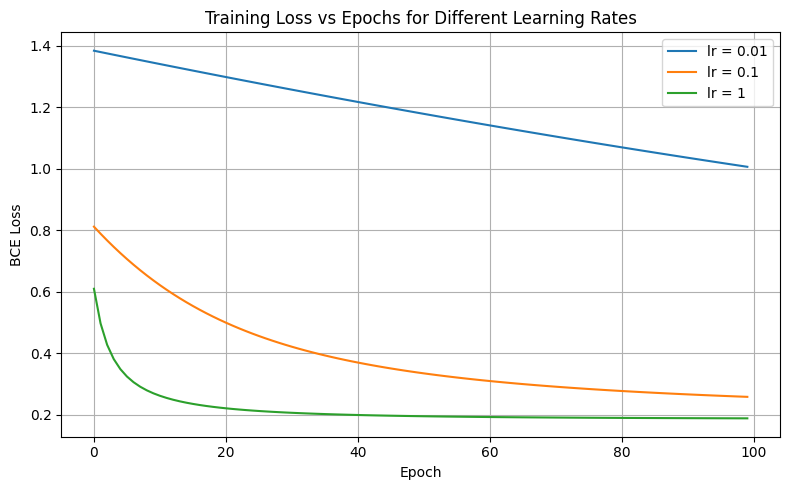

In [ ]:
plt.figure(figsize=(8,5))
for lr, losses in loss_histories.items():
    plt.plot(losses, label=f'lr = {lr}')
plt.title("Training Loss vs Epochs for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Observations
print("\nObservations on learning rate effects:")
print("1) Speed of convergence:")
print("   lr=0.01: Very slow descent, almost flat over 100 epochs")
print("   lr=0.1:  faster early drop and steadier convergence.")
print("   lr=1: Loss may decrease very rapidly initially but can overshoot or plateau.")

print("\n2) Stability of training:")
print("   lr=0.01: Very stable but slow; no oscillations.")
print("   lr=0.1: Good balance, relatively smooth descent.")
print("   lr=1: Unstable—loss curve might fluctuate or even increase at times.")



Observations on learning rate effects:
1) Speed of convergence:
   lr=0.01: Very slow descent, almost flat over 100 epochs
   lr=0.1:  faster early drop and steadier convergence.
   lr=1: Loss may decrease very rapidly initially but can overshoot or plateau.

2) Stability of training:
   lr=0.01: Very stable but slow; no oscillations.
   lr=0.1: Good balance, relatively smooth descent.
   lr=1: Unstable—loss curve might fluctuate or even increase at times.
